In [1]:
#loading from local
import pandas as pd

df = pd.read_parquet("/home/dilmurod/job/tts_project/data/karakalpak-speech-corpus/train-00005-of-00008.parquet")

# as it is only small part of dataset

In [3]:
df.head()

,id,audio,text,raw_text
0,12500,{'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x...,"Belgilengen ilajlar izbe-iz ámelge asırılsa, a...","Belgilengen ilajlar izbe-iz ámelge asırılsa, a..."
1,12501,{'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x...,"Bunnan tısqarı, Saida Mirziyoeva Vena qalasınd...","Bunnan tısqarı, Saida Mirziyoeva Vena qalasınd..."
2,12502,{'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x...,Pidayı hayallarǵa húrmet on besinshi oktyabr -...,Pidayı hayallarǵa húrmet 15-oktyabr – Xalıqara...
3,12503,{'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x...,"Ol tek ǵana málimleme deregi emes, al insan ru...","Ol tek ǵana málimleme deregi emes, al insan ru..."
4,12504,{'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x...,Olar ushın jaratılǵan huqıqıy kepillikler hám ...,Olar ushın jaratılǵan huqıqıy kepillikler hám ...


In [ ]:
# lets listen one sample which after VAD seen ad no speech

import subprocess
from pathlib import Path

i = 12586-12500

# Get audio + text
text = df.iloc[i]["text"]
audio_bytes = df.iloc[i]["audio"]["bytes"]

# Save audio
path = Path(f"sample_{i}.ogg")
path.write_bytes(audio_bytes)

print("Text:", text)
print("Opening:", path.absolute())

# Open with the system's default media player
subprocess.Popen(["xdg-open", str(path.absolute())])

Text: Onda áskeriy xızmetkerler hám olardıń shańaraq aǵzalarınıń sociallıq máselelerine baylanıslı mashqalalarına sheshim tabıldı. Ilajǵa Ózbekstan Respublikası Milliy gvardiyası hám Ayrıqsha jaǵdaylar ministrligi áskeriy xızmetkerleri hám olardıń shańaraq aǵzaları qatnastı.
Opening: /home/dilmurod/job/tts_project/notebooks/sample_86.ogg


<Popen: returncode: None args: ['xdg-open', '/home/dilmurod/job/tts_project/...>

In [2]:
import torch
import torchaudio
import torchaudio.functional as F
import torchaudio.transforms as T

print(torch.__version__)
print(torchaudio.__version__)

2.14.0+cu130
2.11.0+cu130


In [3]:
import math
import timeit

import matplotlib.pyplot as plt
from IPython.display import Audio
import numpy as np

DEFAULT_OFFSET = 201


def _get_log_freq(sample_rate, max_sweep_rate, offset):
    """Get freqs evenly spaced out in log-scale, between [0, max_sweep_rate // 2]

    offset is used to avoid negative infinity `log(offset + x)`.

    """
    start, stop = math.log(offset), math.log(offset + max_sweep_rate // 2)
    return torch.exp(torch.linspace(start, stop, sample_rate, dtype=torch.double)) - offset


def _get_inverse_log_freq(freq, sample_rate, offset):
    """Find the time where the given frequency is given by _get_log_freq"""
    half = sample_rate // 2
    return sample_rate * (math.log(1 + freq / offset) / math.log(1 + half / offset))


def _get_freq_ticks(sample_rate, offset, f_max):
    # Given the original sample rate used for generating the sweep,
    # find the x-axis value where the log-scale major frequency values fall in
    times, freq = [], []
    for exp in range(2, 5):
        for v in range(1, 10):
            f = v * 10**exp
            if f < sample_rate // 2:
                t = _get_inverse_log_freq(f, sample_rate, offset) / sample_rate
                times.append(t)
                freq.append(f)
    t_max = _get_inverse_log_freq(f_max, sample_rate, offset) / sample_rate
    times.append(t_max)
    freq.append(f_max)
    return times, freq


def get_sine_sweep(sample_rate, offset=DEFAULT_OFFSET):
    max_sweep_rate = sample_rate
    freq = _get_log_freq(sample_rate, max_sweep_rate, offset)
    delta = 2 * math.pi * freq / sample_rate
    cummulative = torch.cumsum(delta, dim=0)
    signal = torch.sin(cummulative).unsqueeze(dim=0)
    return signal


def plot_sweep(
    waveform,
    sample_rate,
    title,
    max_sweep_rate=48000,
    offset=DEFAULT_OFFSET,
):
    x_ticks = [100, 500, 1000, 5000, 10000, 20000, max_sweep_rate // 2]
    y_ticks = [1000, 5000, 10000, 20000, sample_rate // 2]

    time, freq = _get_freq_ticks(max_sweep_rate, offset, sample_rate // 2)
    freq_x = [f if f in x_ticks and f <= max_sweep_rate // 2 else None for f in freq]
    freq_y = [f for f in freq if f in y_ticks and 1000 <= f <= sample_rate // 2]

    figure, axis = plt.subplots(1, 1)
    _, _, _, cax = axis.specgram(waveform[0].numpy(), Fs=sample_rate)
    plt.xticks(time, freq_x)
    plt.yticks(freq_y, freq_y)
    axis.set_xlabel("Original Signal Frequency (Hz, log scale)")
    axis.set_ylabel("Waveform Frequency (Hz)")
    axis.xaxis.grid(True, alpha=0.67)
    axis.yaxis.grid(True, alpha=0.67)
    figure.suptitle(f"{title} (sample rate: {sample_rate} Hz)")
    plt.colorbar(cax)

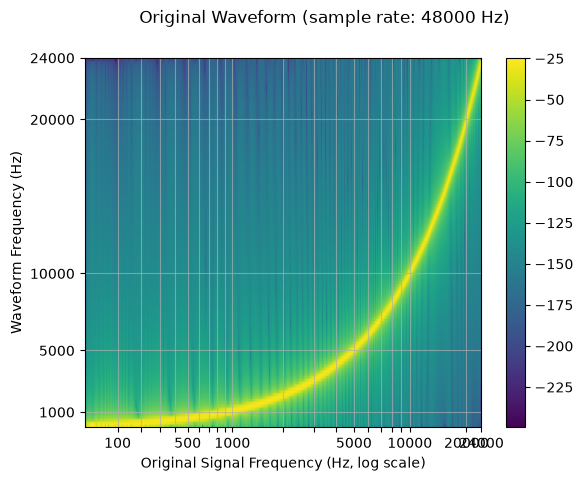

In [4]:
sample_rate = 48000
waveform = get_sine_sweep(sample_rate)

plot_sweep(waveform, sample_rate, title="Original Waveform")
Audio(waveform.numpy()[0], rate=sample_rate)

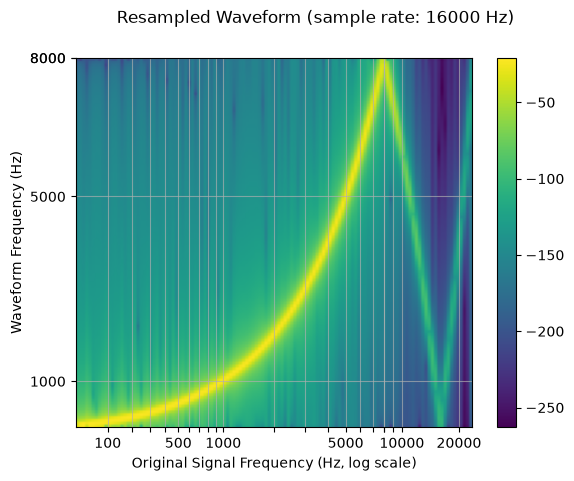

In [6]:
resample_rate = 16000
resampler = T.Resample(sample_rate, resample_rate, dtype=waveform.dtype)
resampled_waveform = resampler(waveform)

plot_sweep(resampled_waveform, resample_rate, title="Resampled Waveform")
Audio(resampled_waveform.numpy()[0], rate=resample_rate)

In [7]:
# resampling using librosa

import io
import librosa
import soundfile as sf

# Example: audio is your dataset's {"bytes": ..., "path": ...} dictionary
audio = df["audio"].iloc[0]

# Load audio and resample directly to 16 kHz
waveform, sr = librosa.load(
    io.BytesIO(audio["bytes"]),
    sr=16000,
    mono=True
)

print("Sample rate:", sr)
print("Samples:", len(waveform))
print("Duration:", len(waveform) / sr, "seconds")

Sample rate: 16000
Samples: 233816
Duration: 14.6135 seconds


In [9]:
# checking channels

import io
import soundfile as sf

audio = df["audio"].iloc[0]

waveform, sr = sf.read(io.BytesIO(audio["bytes"]))

print("Shape:", waveform.shape)
print("Sample rate:", sr)

Shape: (701448,)
Sample rate: 48000


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

In [13]:
# using torch audio

waveform, sr = sf.read(io.BytesIO(audio["bytes"]))

import io
import soundfile as sf
import torch
import torchaudio


audio = df["audio"].iloc[0]

# Decode OGG
waveform, sr = sf.read(io.BytesIO(audio["bytes"]))

# NumPy -> PyTorch tensor
waveform = torch.from_numpy(waveform).float()

# Mono: [samples] -> [1, samples]
if waveform.ndim == 1:
    waveform = waveform.unsqueeze(0)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Move waveform and resampler to the same device
waveform = waveform.to(device)

resampler = torchaudio.transforms.Resample(
    orig_freq=48_000,
    new_freq=16_000
).to(device)

# Resample
resampled = resampler(waveform)

print("Original:", sr, waveform.shape)
print("Resampled:", 16_000, resampled.shape)
print("Device:", resampled.device)

Original: 48000 torch.Size([1, 701448])
Resampled: 16000 torch.Size([1, 233816])
Device: cuda:0


In [10]:

audio = df["audio"].iloc[0]
audio

{'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\xb7\xee\xb0q\x00\x00\x00\x00\x14g\x8ae\x01\x13OpusHead\x01\x018\x01\x80\xbb\x00\x00\x00\x00\x00OggS\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xb7\xee\xb0q\x01\x00\x00\x00uoAq\x03\xff\xff\xfeOpusTags\x15\x00\x00\x00libopus unknown-fixed\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x

VAD 

removing starting and ending silence

In [ ]:
# using Silero VAD

from silero_vad import load_silero_vad, get_speech_timestamps
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = load_silero_vad().to(device)

audio_16k = resampled.squeeze(0).to(device)

timestamps = get_speech_timestamps(
    audio_16k,
    model,
    sampling_rate=16_000,
    threshold=0.5,
    min_speech_duration_ms=250,
    min_silence_duration_ms=100,
    speech_pad_ms=30,
)

print(timestamps)

/home/dilmurod/job/tts_project/.venv/lib/python3.14/site-packages/torch/jit/_serialization.py:170: FutureWarning: `torch.jit.load` is not supported in Python 3.14+ and may break. Please switch to `torch.export`.
  warnings.warn(


[{'start': 8224, 'end': 61920}, {'start': 70688, 'end': 104928}, {'start': 116768, 'end': 135136}, {'start': 137248, 'end': 229856}]


In [15]:
first_start = timestamps[0]["start"]
last_end = timestamps[-1]["end"]

cleaned = audio_16k[first_start:last_end]

In [16]:
from IPython.display import Audio, display

# Original audio (48 kHz)
print("Original audio:")
display(Audio(
    waveform.squeeze().cpu().numpy(),
    rate=48_000
))

# Cleaned 16 kHz audio

cleaned = resampled.squeeze(0)[first_start:last_end]

print("Cleaned audio:")
display(Audio(
    cleaned.cpu().numpy(),
    rate=16_000
))

Original audio:


Cleaned audio:


Use  torch audio for resampling 

use Silero VAD for VAD (removing starting and ending silence)


In [17]:
df.head()

,id,audio,text,raw_text
0,0,{'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x...,Isbilermenlik subektleri ushın xabardar etiw t...,Isbilermenlik subektleri ushın xabardar etiw t...
1,1,{'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x...,Bul jol arqalı Shımbay tek ǵana ishki ekonomik...,Bul jol arqalı Shımbay tek ǵana ishki ekonomik...
2,2,{'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x...,Tutınıw sebetindegi ónim hám xızmetlerdiń jetp...,Tutınıw sebetindegi ónim hám xızmetlerdiń 70 p...
3,3,{'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x...,Jergilikli qatnasıwshılar ushın kórgizbeniń ek...,Jergilikli qatnasıwshılar ushın kórgizbeniń ek...
4,4,{'bytes': b'OggS\x00\x02\x00\x00\x00\x00\x00\x...,"Sessiyanıń kún tártibindegi dáslepki másele ""Q...",Sessiyanıń kún tártibindegi dáslepki másele «Q...
